In [41]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import pandas as pd

from popt.config import bond, sect, intn, universe

In [42]:
D0 = "2005-01-03"
D1 = "2024-12-31"

rd = pd.read_parquet("../data/return/return_d.parquet").loc[D0:D1]
rf = pd.read_parquet("../data/return/ffr_d.parquet").reindex(rd.index)
rd.shape, rf.shape

((5033, 56), (5033, 1))

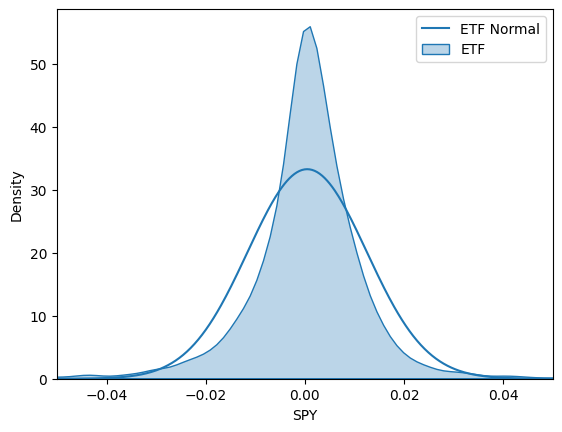

(np.float64(0.00046050715142146817), np.float64(0.011989823790912742))

In [43]:
D0_ = "2005-01-03"
D1_ = "2010-01-03"
D2_ = "2015-01-03"
D3_ = "2020-01-03"
D4_ = "2025-01-03"

etf = rd["SPY"].loc[D0_:D4_]
mu = etf.mean()
sigma = etf.std()

norm_pdf = lambda x: 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-0.5 * (x - mu)**2 / sigma**2)
x = np.linspace(etf.min(), etf.max(), 1000)

plt.plot(x, norm_pdf(x), label="ETF Normal")
sns.kdeplot(etf, label="ETF", fill=True, alpha=0.3)
plt.xlim(-0.05, 0.05)
plt.legend()
plt.show()
mu, sigma

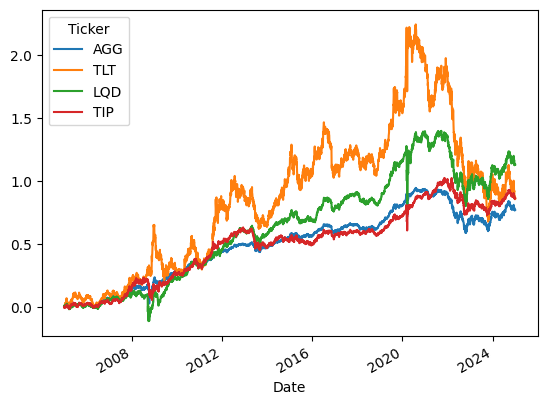

In [44]:
subset = rd[[
    # "SPY",
    # "XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB",
    # "IYR", "IBB",
    # "GLD", "SLV", "CPER", "PPLT",
    # *metl,
    *bond,
    # "CMBS", "HYXU", "TLTW", "GOVT", "FALN", "EMHY", "LEMB", "SHYG", # "GOVZ", "ICVT",
]].loc[D0_:D4_]
r_cumu = (subset+1.0).cumprod()-1.0
r_cumu.plot(legend=True)
plt.show()

In [45]:
def sharpe_geom(
        rd: pd.DataFrame, 
        rf: pd.Series,
        ):
    assert rd.index.equals(rf.index)
    sharpes = {}
    for col in rd.columns:
        rd_i = rd[col].dropna()
        rf_i = rf.reindex(rd_i.index).fillna(0.0).to_numpy()
        num_days = rd_i.shape[0]
        ret_ann = ((1.0 + rd_i).prod(axis=0) / (1.0 + rf_i).prod()) ** (252 / num_days) - 1.0
        vol_ann = rd_i.std() * np.sqrt(252)
        sharpes[col] = ret_ann / vol_ann
    return pd.Series(sharpes)

def annual_return(rd: pd.DataFrame) -> pd.Series:
    num_days = rd.notna().sum(axis=0)
    return (1.0+rd).prod() ** (252 / num_days)-1.0

def annual_volatility(rd: pd.DataFrame) -> pd.Series:
    return rd.std() * np.sqrt(252)

def total_return(rd: pd.DataFrame) -> pd.Series:
    return (1.0+rd).prod()-1.0

stats = pd.DataFrame({
    "sharpe": sharpe_geom(rd, rf),
    "ret ann": annual_return(rd),
    "vol ann": annual_volatility(rd),
    "ret tot": total_return(rd),
}, index=rd.columns)

In [53]:
num_days = rd["USMV"].notna().sum(axis=0)
(1.0+rd["USMV"]).prod() ** (252 / num_days)-1.0

np.float64(0.12123032472556217)

In [54]:
num_days

np.int64(3319)

In [46]:
stats.sort_values(by="sharpe", ascending=False).head(60)

,sharpe,ret ann,vol ann,ret tot
Ticker,,,,
USMV,0.780031,0.121230,0.136114,3.513490
SCHD,0.735548,0.129187,0.155017,3.954034
QUAL,0.678061,0.134171,0.172365,3.222308
QQQ,0.585891,0.144971,0.215396,13.936726
XLK,0.559025,0.142343,0.221124,13.266692
XLP,0.520728,0.091304,0.140980,4.726171
VUG,0.512054,0.121523,0.201415,8.880579
XLV,0.476867,0.097317,0.166348,5.390293
SPY,0.445346,0.102845,0.190333,6.064992


In [47]:
rd[[
    "SPY",
    *bond,
    # "CMBS", "HYXU", "TLTW", "GOVT", "FALN", "EMHY", "LEMB", "ICVT", "SHYG", "GOVZ",
]].corr()

Ticker,SPY,AGG,TLT,LQD,TIP
Ticker,,,,,
SPY,1.000000,-0.010334,-0.323821,0.187871,-0.110603
AGG,-0.010334,1.000000,0.703579,0.700792,0.674272
TLT,-0.323821,0.703579,1.000000,0.539521,0.701493
LQD,0.187871,0.700792,0.539521,1.000000,0.532000
TIP,-0.110603,0.674272,0.701493,0.532000,1.000000
